In [1]:
import re
import random
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

import kagglehub
import os

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

MY_SEED = 22
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cuda
MY_SEED = 22


## 10. Идеи для самостоятельных вариаций (для вашей работы со своим датасетом)

В своей версии лабораторной работы вы должны будете:
- взять **реальный** текстовый датасет (отзывы, комментарии, заголовки новостей и т.п.);
- реализовать ту же цепочку: токенизация → словарь → паддинг → LSTM/GRU;
- поэкспериментировать минимум с двумя архитектурами (например, LSTM vs GRU, 1 vs 2 слоя, разный `hidden_dim`/`embed_dim`);
- сравнить результаты по валидaции/тесту и описать найденные закономерности.

Этот ноутбук даёт только пример на упрощённых данных. Ваш основной вклад - перенос идеи на реальную задачу и её качественный анализ.


## Ниже реалзуйте обучение на своём датасете
У вас всё получится! (быстро же всё обучается)

In [31]:
# Заглушка под ваш код

# беру датасет из kaggle
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

csv_path = os.path.join(path, "IMDB Dataset.csv")
df = pd.read_csv(csv_path)

# перевести метки в 0/1
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# возьмем 100 примеров
df = df.sample(100, random_state=MY_SEED)


# финальный датасет
my_df = df[["review", "label"]].rename(columns={"review": "text"})

print(my_df.head())
print("Размер датасета:", my_df.shape)
print("Распределение классов:\n", my_df["label"].value_counts())

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
                                                    text  label
20920  I know John Singleton's a smart guy 'coz he ma...      0
21590  1) If you want to make a movie that deals with...      0
21586  Once you pick your jaw up from off the floor f...      1
41939  "The Beguiled" is one of my favorite Clint Eas...      1
25260  Every time I watch this show I just want to tu...      1
Размер датасета: (100, 2)
Распределение классов:
 label
0    52
1    48
Name: count, dtype: int64


In [32]:
def simple_tokenize(text: str):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    return tokens

my_df["tokens"] = my_df["text"].apply(simple_tokenize)
print(my_df[["text", "tokens"]].head())

                                                    text  \
20920  I know John Singleton's a smart guy 'coz he ma...   
21590  1) If you want to make a movie that deals with...   
21586  Once you pick your jaw up from off the floor f...   
41939  "The Beguiled" is one of my favorite Clint Eas...   
25260  Every time I watch this show I just want to tu...   

                                                  tokens  
20920  [i, know, john, singletons, a, smart, guy, coz...  
21590  [if, you, want, to, make, a, movie, that, deal...  
21586  [once, you, pick, your, jaw, up, from, off, th...  
41939  [the, beguiled, is, one, of, my, favorite, cli...  
25260  [every, time, i, watch, this, show, i, just, w...  


In [33]:
# Подсчёт частот слов и построение словаря
word_counts = {}
for tokens in my_df["tokens"]:
    for w in tokens:
        word_counts[w] = word_counts.get(w, 0) + 1

sorted_words = sorted(word_counts.items(), key=lambda x: -x[1])

word2idx = {"<PAD>": 0, "<UNK>": 1}
for w, c in sorted_words:
    word2idx[w] = len(word2idx)

idx2word = {idx: w for w, idx in word2idx.items()}

print("Размер словаря:", len(word2idx))
print("Первые элементы словаря:", list(word2idx.items())[:10])

Размер словаря: 5106
Первые элементы словаря: [('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('a', 3), ('and', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('i', 9)]


In [34]:
def encode_tokens(tokens, word2idx):
    return [word2idx.get(w, word2idx["<UNK>"]) for w in tokens]

my_df["encoded"] = my_df["tokens"].apply(lambda t: encode_tokens(t, word2idx))
print(my_df[["tokens", "encoded"]].head())

lengths = my_df["encoded"].apply(len)
print("Мин и макс длины последовательностей:", lengths.min(), lengths.max())
max_len = 200 #int(lengths.max())  # для примера берём максимум
print("max_len =", max_len)

                                                  tokens  \
20920  [i, know, john, singletons, a, smart, guy, coz...   
21590  [if, you, want, to, make, a, movie, that, deal...   
21586  [once, you, pick, your, jaw, up, from, off, th...   
41939  [the, beguiled, is, one, of, my, favorite, cli...   
25260  [every, time, i, watch, this, show, i, just, w...   

                                                 encoded  
20920  [9, 156, 383, 1996, 3, 673, 174, 1997, 23, 107...  
21590  [48, 27, 175, 6, 111, 3, 17, 12, 1241, 15, 124...  
21586  [345, 27, 904, 157, 1247, 58, 38, 120, 2, 1248...  
41939  [2, 2051, 7, 30, 5, 57, 691, 1259, 463, 88, 4,...  
25260  [129, 52, 9, 98, 11, 114, 9, 36, 175, 6, 203, ...  
Мин и макс длины последовательностей: 49 957
max_len = 200


In [35]:
def pad_sequence(seq, max_len, pad_idx=0):
    if len(seq) < max_len:
        return seq + [pad_idx] * (max_len - len(seq))
    else:
        return seq[:max_len]

my_df["padded"] = my_df["encoded"].apply(lambda s: pad_sequence(s, max_len, pad_idx=word2idx["<PAD>"]))
print(my_df[["encoded", "padded"]].head())

                                                 encoded  \
20920  [9, 156, 383, 1996, 3, 673, 174, 1997, 23, 107...   
21590  [48, 27, 175, 6, 111, 3, 17, 12, 1241, 15, 124...   
21586  [345, 27, 904, 157, 1247, 58, 38, 120, 2, 1248...   
41939  [2, 2051, 7, 30, 5, 57, 691, 1259, 463, 88, 4,...   
25260  [129, 52, 9, 98, 11, 114, 9, 36, 175, 6, 203, ...   

                                                  padded  
20920  [9, 156, 383, 1996, 3, 673, 174, 1997, 23, 107...  
21590  [48, 27, 175, 6, 111, 3, 17, 12, 1241, 15, 124...  
21586  [345, 27, 904, 157, 1247, 58, 38, 120, 2, 1248...  
41939  [2, 2051, 7, 30, 5, 57, 691, 1259, 463, 88, 4,...  
25260  [129, 52, 9, 98, 11, 114, 9, 36, 175, 6, 203, ...  


In [36]:
X = np.stack(my_df["padded"].values)
y = my_df["label"].values.astype(np.int64)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=MY_SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=MY_SEED, stratify=y_temp
)

print("Размеры:")
print("  train:", X_train.shape)
print("  val  :", X_val.shape)
print("  test :", X_test.shape)

Размеры:
  train: (60, 200)
  val  : (20, 200)
  test : (20, 200)


In [37]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Кол-во батчей в train_loader:", len(train_loader))

Кол-во батчей в train_loader: 4


In [38]:
# # модель LSTM
# vocab_size = len(word2idx)
# embed_dim = 64
# hidden_dim = 64
# num_layers = 1
# num_classes = 2

# class SimpleLSTMClassifier(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
#         self.lstm = nn.LSTM(
#             input_size=embed_dim,
#             hidden_size=hidden_dim,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=0.3
#         )
#         self.fc = nn.Linear(hidden_dim, num_classes)

#     def forward(self, x):
#         emb = self.embedding(x)              # [B, T] -> [B, T, E]
#         output, (h_n, c_n) = self.lstm(emb)  # h_n: [L, B, H]
#         last_hidden = h_n[-1]                # [B, H] — последнее по времени состояние верхнего слоя
#         logits = self.fc(last_hidden)
#         return logits

# model = SimpleLSTMClassifier(
#     vocab_size=vocab_size,
#     embed_dim=embed_dim,
#     hidden_dim=hidden_dim,
#     num_layers=num_layers,
#     num_classes=num_classes,
#     pad_idx=word2idx["<PAD>"]
# ).to(device)

# print(model)

In [49]:
# модель GRU
vocab_size = len(word2idx)
embed_dim = 16
hidden_dim = 128
num_layers = 1
num_classes = 2

class SimpleGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        output, h_n = self.gru(emb)
        last_hidden = h_n[-1]
        logits = self.fc(last_hidden)
        return logits


model = SimpleGRUClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    num_classes=num_classes,
    pad_idx=word2idx["<PAD>"]
).to(device)

print(model)

SimpleGRUClassifier(
  (embedding): Embedding(5106, 16, padding_idx=0)
  (gru): GRU(16, 128, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


In [50]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001


In [51]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)

    return total_loss / total, total_correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)

    return total_loss / total, total_correct / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [52]:
num_epochs = 15
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

Эпоха 1/15: train_loss=0.7016, train_acc=0.4000, val_loss=0.7025, val_acc=0.4500
Эпоха 2/15: train_loss=0.6815, train_acc=0.5500, val_loss=0.6931, val_acc=0.5000
Эпоха 3/15: train_loss=0.6691, train_acc=0.6333, val_loss=0.6816, val_acc=0.6500
Эпоха 4/15: train_loss=0.6568, train_acc=0.7167, val_loss=0.6708, val_acc=0.6500
Эпоха 5/15: train_loss=0.6397, train_acc=0.7333, val_loss=0.6630, val_acc=0.6000
Эпоха 6/15: train_loss=0.6231, train_acc=0.7667, val_loss=0.6517, val_acc=0.6000
Эпоха 7/15: train_loss=0.6009, train_acc=0.8000, val_loss=0.6405, val_acc=0.6000
Эпоха 8/15: train_loss=0.5758, train_acc=0.8000, val_loss=0.6198, val_acc=0.6500
Эпоха 9/15: train_loss=0.5376, train_acc=0.7833, val_loss=0.5988, val_acc=0.6500
Эпоха 10/15: train_loss=0.5006, train_acc=0.7500, val_loss=0.5730, val_acc=0.7000
Эпоха 11/15: train_loss=0.4726, train_acc=0.7500, val_loss=0.5836, val_acc=0.7500
Эпоха 12/15: train_loss=0.4344, train_acc=0.7667, val_loss=0.5991, val_acc=0.6500
Эпоха 13/15: train_loss=0

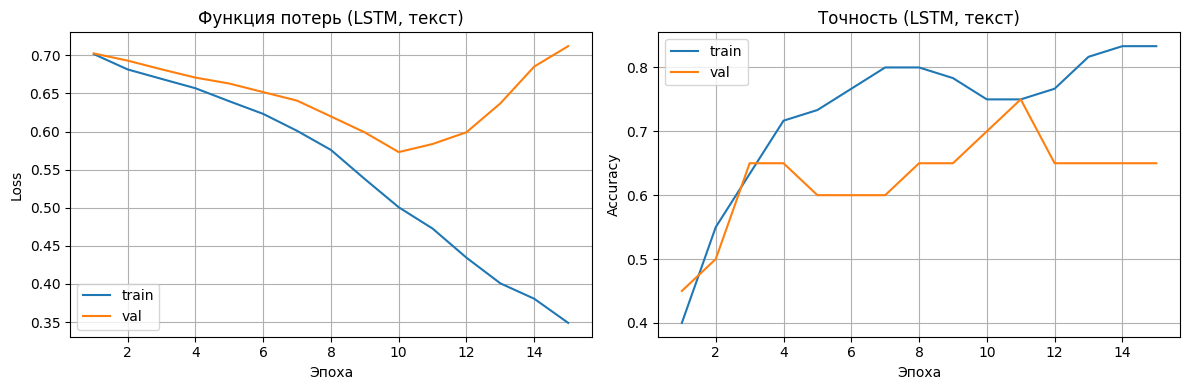

Финальные метрики: train_acc=0.8333, val_acc=0.6500


In [53]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Функция потерь (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train")
plt.plot(epochs, history["val_acc"], label="val")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Точность (LSTM, текст)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальные метрики: train_acc={history['train_acc'][-1]:.4f}, val_acc={history['val_acc'][-1]:.4f}")

In [54]:
final_summary = """ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ:
какие архитектуры пробовали,
какие настройки оказались наиболее важными и какие правила вы для себя
сформулировали по настройке RNN для текстов.

В эксперименте со своим датасетом я протестировала две сети: LSTM и GRU на примерах из отзывов на фильме IMDB с сайта Kaggle.
Я взала 100 примеров, поскольку отзывы достаточно длинные.
Пробовала и с 1 слоем, и с 2 на обеих сетях.
embed_dim и hidden_dim пробовала: 16, 32, 64, 128.
Больше всего качество по моему мнению зависит от них.
Также добавила dropout

Честно, не заметила каких-то закономерностей. Думаю размер эмбеддингов стоит ставить ниже, а размерность скрытых состояний чуть выше.
"""
print(final_summary)

ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ:
какие архитектуры пробовали,
какие настройки оказались наиболее важными и какие правила вы для себя
сформулировали по настройке RNN для текстов.

В эксперименте со своим датасетом я протестировала две сети: LSTM и GRU на примерах из отзывов на фильме IMDB с сайта Kaggle.
Я взала 100 примеров, поскольку отзывы достаточно длинные. 
Пробовала и с 1 слоем, и с 2 на обеих сетях.
embed_dim и hidden_dim пробовала: 16, 32, 64, 128.
Больше всего качество по моему мнению зависит от них.
Также добавила dropout

Честно, не заметила каких-то закономерностей. Думаю размер эмбеддингов стоит ставить ниже, а размерность скрытых состояний чуть выше.

